# Домашняя работа. Проблема качества данных.

## Задание

Проведите очистку данных на примере датасета с информацией о пассажирах корабля Титаник. На полученных данных обучите модель классификации, с целевым признаком Survived (1 – пассажир выжил, 0 – погиб). Обучите модель на необработанных данных и посчитайте метрику качества. Проведите очистку данных. Обучите модель на данных после обработки, посчитайте метрику качества. Сравнить полученные результаты. Значение метрики должно улучшиться.

Этапы работы:

- Получите и загрузите данные.
- Удалите все пропущенные значения и категориальные переменные. Обучите модель. Выберете и посчитайте метрику качества.
- Снова загрузите полные данные.
- Удалите признаки, которые логически не нужны для построения модели. Обоснуйте.
- Проверьте данные на наличие пропущенных значений.
    - Посчитайте, какой процент данных будет потерян, если просто удалить пропуски.
    - Заполните пропуски: средним значением; константой; классом, указывающим на то, что значение было пропущено; случайным числом. Для разных признаков используйте подходящий метод. Можно не использовать все перечисленные методы.
- Категориальные переменные переведите в цифровые значения. Можно использовать pd.get_dummies, preprocessing.LabelEncoder. Старайтесь не использовать для этой задачи циклы.
- Проверьте данные на наличие выбросов. Удалите выбросы, если считаете это целесообразным. Обоснуйте.
- Постройте 1-2 графика на выбор. Визуализация должна быть основана на исследуемых данных и быть полезной (из графика можно сделать вывод об особенностях датасета/класса/признака)
- Попробуйте математически преобразовать признак Age.
- Обучите ту же модель, что в п. 2 на преобразованных данных. Посчитайте ту же, что в п. 2 метрику.
- Сформулируйте выводы по проделанной работе.
    - Кратко опишите какие преобразования были сделаны и почему.
    - Сравните метрики моделей из п. 2 и п. 10.
    - Напишите свое мнение о целесообразности работы с данными при построении моделей машинного обучения.
- Нужно ли аналогичным образом исследовать и дополнять действительно большие данные?

Для получения зачета по этому домашнему заданию, минимально, должно быть построено две модели, выведена одна метрика для каждой. В данных должны быть обработаны пропуски и категориальные значения.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sbrn
from sklearn import preprocessing, svm

## Получите и загрузите данные

In [2]:
DSTrain = pd.read_csv('train.csv')
DSTest = pd.read_csv('test.csv')
DSTestAnswers = pd.read_csv('gender_submission.csv')
assert DSTest['PassengerId'].equals(DSTestAnswers['PassengerId'])
# Объединим тестовые датасеты в один, 
# чтобы при модификации тестового датасета ответы были модифицированы тоже
DSTest['Survived'] = DSTestAnswers['Survived']
DSTrain.info()
DSTrain.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Удалите все пропущенные значения и категориальные переменные

In [3]:
# Сперва удалим категорияльнае признаки, чтобы их NaN значения не приводили к лишнему удалению данных 
category_features = ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
DSTrainNoNanNoCat = DSTrain.drop(axis = 'columns', labels=category_features).dropna()
DSTestNoNanNoCat = DSTest.drop(axis = 'columns', labels=category_features).dropna()
DSTrainNoNanNoCat.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  714 non-null    int64  
 1   Survived     714 non-null    int64  
 2   Pclass       714 non-null    int64  
 3   Age          714 non-null    float64
 4   SibSp        714 non-null    int64  
 5   Parch        714 non-null    int64  
 6   Fare         714 non-null    float64
dtypes: float64(2), int64(5)
memory usage: 44.6 KB


## Обучите модель

In [4]:
def svc_train(train):
    X_train = train.drop('Survived', axis = 1)
    Y_train = train['Survived']
    svm_model = svm.SVC()
    svm_model.fit(X_train, Y_train )
    return svm_model
    
def svc_train_test(train, test):
    svc_model = svc_train(train)
    X_test = test.drop('Survived', axis = 1)
    Y_test = test['Survived']
    return svc_model.score(X_test, Y_test)

noNanNoCatScore = svc_train_test(DSTrainNoNanNoCat, DSTestNoNanNoCat)
noNanNoCatScore

0.6344410876132931

## Удалите признаки, которые логически не нужны

In [5]:
# PassengerId - просто идентификатор, не несет никакой информации, которая может как-то быть связана 
# с шансами на выживание, либо такая интерпретация неизвестна
# Name - имя не влияет на выживаемость, если оно не Беар Гриллс
# Embarked - трудно предположить, что место посадки как-то влияет на шансы выжить
# Cabin - возможно номер каюты и тип как-то связаны с ее положением на судне и как следствие 
# шансами выжить, но для использования этого нужно как-то их преобразовать неизвестным нам способом, 
# к тому же, у нас слишком мало заполненных значени этого признака.
# DSTrain['Cabin'].isna().sum()
# Ticket - номер билета, трудно предположить, что он как-то связан с шансами выжить.
# SibSp, Parch - удалил постфактум, удаление признаков не влияет на результат
# Fare - ожидаю, что должно коррелировать с "хорошим" расположением каюты, более высокой палубой и т.п.
DSTrain = DSTrain.drop(['PassengerId', 'Name', 'Embarked', 'Cabin', 'Ticket', 'SibSp', 'Parch'], axis=1)
DSTest = DSTest.drop(['PassengerId', 'Name', 'Embarked', 'Cabin', 'Ticket', 'SibSp', 'Parch'], axis=1)

## Проверьте данные на наличие пропущенных значений

### Какой процент данных будет потерян, если просто удалить пропуски?

In [6]:
data_loss_on_simple_nan_remove = 100 * (1 - (float(len(DSTrainNoNanNoCat.index)) / len(DSTrain.index)))
data_loss_on_simple_nan_remove

19.865319865319865

## Заполните пропуски

Средним значением; константой; классом, указывающим на то, что значение было пропущено; случайным числом. Для разных признаков используйте подходящий метод. Можно не использовать все перечисленные методы.

In [7]:
# После всех преобразований незаполненными отсутствующие значения остались только в признаке Age.
# Для повышения читабельности объявим функции здесь, а применим их уже после удаления выбросов 
# и преобразования категорияльных признаков, чтобы не делать указанные процедуры несколько раз.

def fillMean(X, column):
    X.loc[X[X[column].isna()].index, column] = X[column].mean()    

def fillMode(X, column):
    X[X[X[column].isna()].index, column] = X[column].mode()

def fillRandomFloat(X, column, seed = 42, min_val = None, max_val = None):
    rng = np.random.default_rng(seed)
    X.loc[X[X[column].isna()].index, column] = rng.uniform(low = min_val, high = max_val)

def fillRandomInt(X, column, seed = 42, min_val = None, max_val = None):
    rng = np.random.default_rng(seed)
    X.loc[X[X[column].isna()].index, column] = rng.integers(low = min_val, high = max_val)

def fillWithIndicator(X, column):
    X['ind_'+str(column)] = 0
    X.loc[X[X[column].isna()].index, 'ind_'+str(column)] = 1
    X.loc[X[X[column].isna()].index, column] = 0

## Категориальные переменные переведите в цифровые значения.

In [8]:
# из категориальных остался один признак Sex, закодируем его
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(DSTest['Sex'])
DSTest['Sex'] = le.transform(DSTest['Sex'])
le.fit(DSTrain['Sex'])
DSTrain['Sex'] = le.transform(DSTrain['Sex'])

# Попробовал закодировать класс пассажира, чтобы модель не сравнивала их между собой
# Это добавило пол процента, т.е. почти бесполезно. 
# Видимо значение класса пассажира в определенной степени коррелирует с целевым признаком.
#DSTrain = pd.get_dummies( DSTrain, columns = [ 'Pclass' ] )
#DSTest = pd.get_dummies( DSTest, columns = [ 'Pclass' ] )

## Проверьте данные на наличие выбросов. Удалите выбросы.

In [9]:
DSTrain.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000
mean,0.383838,2.308642,0.647587,29.699118,32.204208
std,0.486592,0.836071,0.477990,14.526497,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,20.125000,7.910400
50%,0.000000,3.000000,1.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,38.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


<Axes: xlabel='Age'>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

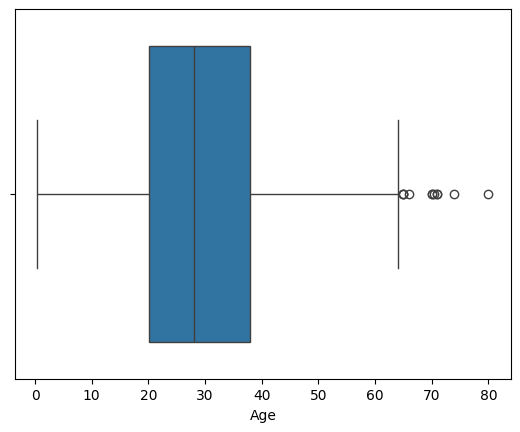

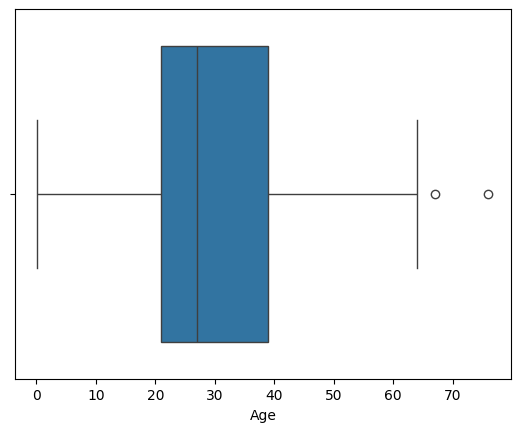

In [10]:
plt.figure()
#sbrn.boxplot(x=DSTrain['Fare'])
plt.figure()
#sbrn.boxplot(x=DSTest['Fare'])
#DSTrain[DSTrain.Fare > 300].index
# Решил не удалять найденные экстремальные значения, таких значений несколько, цифры в принципе
# реалистичные, делаю вывод, что это не ошибка данных а настоящая цена билета 1-го класса
#DSTrain.drop(DSTrain[DSTrain.Fare > 80].index, inplace = True)
#DSTest.drop(DSTest[DSTest.Fare > 80].index, inplace = True)

# В возрасте решил, что выбросов нет, все данные вполне реальные.
plt.figure()
sbrn.boxplot(x=DSTrain['Age'])
plt.figure()
sbrn.boxplot(x=DSTest['Age'])

## Постройте графики

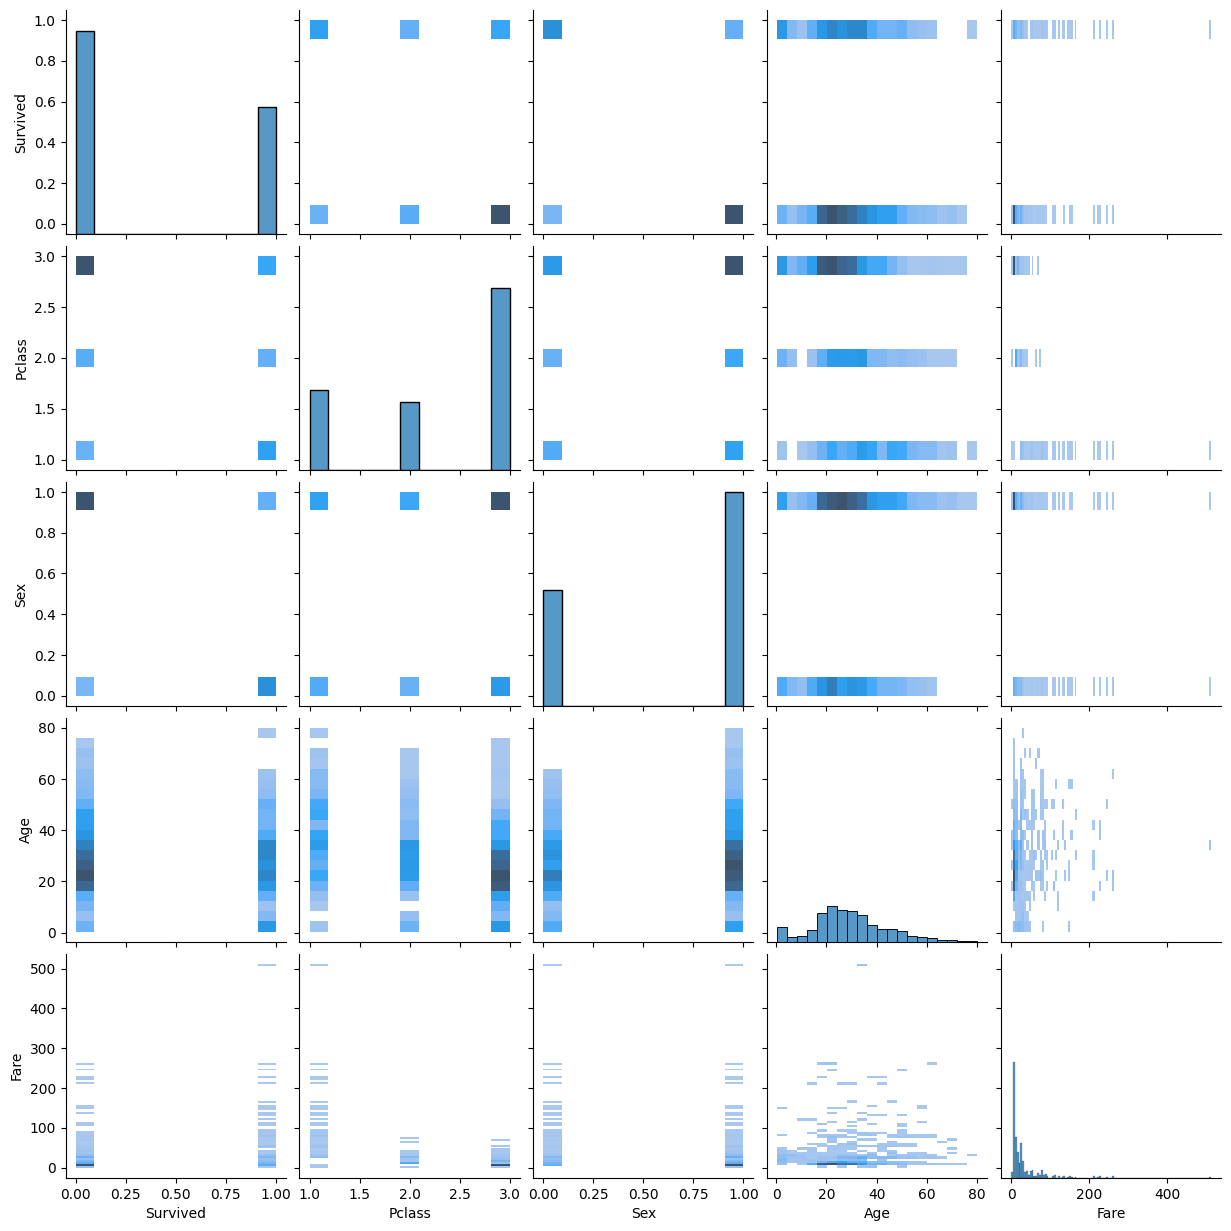

In [11]:
sbrn.pairplot(DSTrain, kind="hist")

In [12]:
# Делаю вывод, что Fare и Age почти не коррелируют с целевым признаком, удалю Fare, Age пока оставлю
DSTrain = DSTrain.drop(['Fare'], axis=1)
DSTest = DSTest.drop(['Fare'], axis=1)


## Обучите ту же модель, что в п. 2 на преобразованных данных

In [13]:
# У нас незаполненные данные содержат только признаки Age и Fare, преобразуем его разными способами
DSTrainMean = DSTrain.copy()
DSTestMean = DSTest.copy()
fillMean(DSTrainMean, 'Age')
# Не уверен, что правильно считать среднее на каждом подмножестве отдельно.
fillMean(DSTestMean, 'Age')
fillMeanScore = svc_train_test(DSTrainMean, DSTestMean)
fillMeanScore

0.631578947368421

In [14]:
# У нас незаполненные данные содержат только признаки Age и Fare, преобразуем его разными способами
DSTrainRandom = DSTrain.copy()
DSTestRandom = DSTest.copy()
fillRandomFloat(DSTrainRandom, 'Age', seed = 0, min_val = 0, max_val = 80)
fillRandomFloat(DSTestRandom, 'Age', seed = 1, min_val = 0, max_val = 80)
fillRandomScore = svc_train_test(DSTrainRandom, DSTestRandom)
fillRandomScore

0.631578947368421

In [15]:
# У нас незаполненные данные содержат только признаки Age и Fare, преобразуем его разными способами
DSTrainIndicator = DSTrain.copy()
DSTestIndicator = DSTest.copy()
fillWithIndicator(DSTrainIndicator, 'Age')
fillWithIndicator(DSTestIndicator, 'Age')
fillIndicatorScore = svc_train_test(DSTrainIndicator, DSTestIndicator)
fillIndicatorScore

0.6363636363636364

## Попробуйте преобразовать Возраст

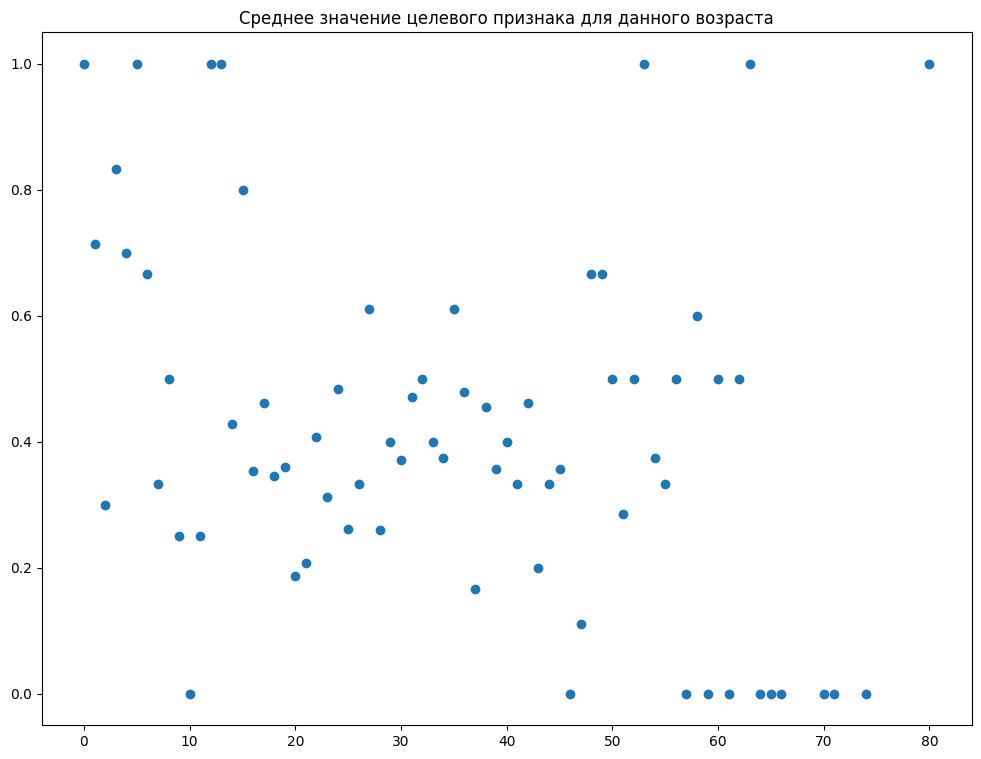

In [16]:
# Проанализируем зависимость целевого признака от возраста

DSAgeServivedDist = DSTrain[['Age', 'Survived']]
DSAgeServivedDist.dropna()
DSAgeServivedDist.loc[:, 'Age'] = DSAgeServivedDist['Age'].apply(lambda x:np.floor(x))
DSAgeServivedDist = DSAgeServivedDist.groupby('Age')['Survived'].mean().reset_index()

plt.figure(figsize=(12,9))
plt.title('Среднее значение целевого признака для данного возраста')
plt.plot(DSAgeServivedDist['Age'], DSAgeServivedDist['Survived'], 'o', color='C0')
plt.show()

In [17]:
# Попробуем разбить возраст на несколько групп и превратить в класс
# выделим несколько групп - очень условно глядя на график выделим детей (<14), 
# взрослых и не старых (<55), пожилых (>=55)

# Сперва удалим пропуски
DSTrainAgeClass = DSTrain.copy()
DSTestAgeClass = DSTest.copy()
fillMean(DSTrainAgeClass, 'Age')
fillMean(DSTestAgeClass, 'Age')

def age_class(age):
    if (age < 14):
        return 0
    if (age < 55):
        return 1
    return 2

DSTrainAgeClass.loc[:, 'Age'] = DSTrainAgeClass['Age'].apply(age_class)
DSTestAgeClass.loc[:, 'Age'] = DSTestAgeClass['Age'].apply(age_class)

# Превращение классов возрастов в "несравниваемые" величины добавляют несклоько процентов
DSTrainAgeClass = pd.get_dummies( DSTrainAgeClass, columns = [ 'Age' ] )
DSTestAgeClass = pd.get_dummies( DSTestAgeClass, columns = [ 'Age' ] )

ageClassScore = svc_train_test(DSTrainAgeClass, DSTestAgeClass)
ageClassScore

0.9904306220095693

In [18]:
# Попробуем нормализовать возраст

# Сперва удалим пропуски
DSTrainAgeStd = DSTrain.copy()
DSTestAgeStd = DSTest.copy()
fillMean(DSTrainAgeStd, 'Age')
fillMean(DSTestAgeStd, 'Age')

scaler = preprocessing.StandardScaler()
DSTrainAgeStd['Age'] = scaler.fit_transform(DSTrainAgeStd[['Age']])
DSTestAgeStd['Age'] = scaler.fit_transform(DSTestAgeStd[['Age']])

ageStdScore = svc_train_test(DSTrainAgeStd, DSTestAgeStd)
ageStdScore

0.9760765550239234

## Выводы

Кратко опишите какие преобразования были сделаны и почему.
    - Сравните метрики моделей из п. 2 и п. 10.
    - Напишите свое мнение о целесообразности работы с данными при построении моделей машинного обучения.
- Нужно ли аналогичным образом исследовать и дополнять действительно большие данные?

- Были удалены "ненужные" признаки. Часть исходя из их смысла, который я воспринял как несвязанный с работой модели, часть исходя из анализа их влияния на модель.
- Были добавлены значения в возраст как единственный оставшийся признак, который содержал пропуски. Сильной разницы между методами заполнения пропущенных значений не увидел, сам эффект от такого заполнения - примерно 2% к финальной метрике. Удивительно, что удаление Fare значительно улучшает метрику. По графику видно, что Fare не коррелирует с целевыи признаком, но почему его наличие так портит результат я так и не понял. Также заметил, что в тестовой выборке есть абсолютная корреляция с полом, т.е. можно удалить Age и получить результат 1.0, работая только с полом и классом пассажира.

Делаю вывод, что анализировать и обрабатывать данные очевидно нужно. Не все методы попробовал здесь, но общий арсенал понятен. Важно оценивать какие признаки нам в принципе нужны, чтобы не обрабатывать ненужное, также важно оценивать какой процент потерян - я пробовал отбросить от Cabin номер каюты, оставив только букву, поскольку судя по чертежам она отвечает за ту или иную палубу, но потом заметил, что у нас очень мало данных, т.е. мы будем придумывать порядка 70% данных, решил, что это скорее вредно. Интересный эффект получился от кластеризации Age, но возможно он связан с тем, что очень сильна корреляция между Sex и Survived.